# Contents
In this notebook, I train a VanillaVAE similarly to the previous one. The difference here is that the model is trained to produce images with a similar degradation as in the last step of the JPEG degradation. In this way, the generation should give better results.


Changes:
- HIDDEN_DIMS=[32,64,128,256,512,512] (6 layers, 128x128 images),
- BATCH_SIZE=32 (reduced because images are 4 times bigger),
-  the dataset (DegradedFaceDataset)applies  jpeg_degrade_step9_stateless on all images before giving them to the VAE.

In [1]:
TRAIN = True

In [2]:
! pip install kornia
! pip install torch_dct

In [3]:
import os
import sys
import glob
import time
import torch
import torch.nn.functional as F
from torch import optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import torch_dct as dct
import kornia

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# CONFIGS
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/tesi/" \
    if 'google.colab' in str(get_ipython()) else "."

PYTORCH_VAE_REPO    = os.path.join(BASE_DIR, 'src/PyTorch-VAE-master')
LOCAL_DATA_ROOT           = '/content/raw_data'
QUANT_TABLES_PATH   = os.path.join(BASE_DIR, 'assets/dequant-quant3_qt.pt')
SAVE_PATH           = os.path.join(BASE_DIR, 'trained_models', 'vae',
                                   'vae_blur_checkpoint_128x128.pt')
ZIP_PATH = os.path.join(BASE_DIR, "data", "img_align_celeba.zip")

HIDDEN_DIMS     = [32, 64, 128, 256, 512, 512]  # 6 layers, last must be 512
LATENT_DIM      = 128
PATCH_SIZE      = 128       # = 2 * 2**len(HIDDEN_DIMS) = 2 * 64 = 128

BATCH_SIZE              = 32
LR                      = 0.005
WEIGHT_DECAY            = 0.0
SCHEDULER_GAMMA         = 0.95
KLD_WEIGHT_MAX          = 0.01     # final value
ANNEALING_STEPS         = 3000     # steps to go from 0 to KLD_WEIGHT_MAX
RESUME                  = False
ADDITIONAL_EPOCHS       = 1
DEVICE                  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LOG_EVERY               = 50
CHECKPOINT_EVERY_STEPS  = 300

In [6]:
if not os.path.exists(LOCAL_DATA_ROOT):
    print("Unzipping ...")
    !unzip -q "{ZIP_PATH}" -d {LOCAL_DATA_ROOT}
    print("Done!")
else:
    print("Already unzipped")


dataset_path = os.path.join(LOCAL_DATA_ROOT, "img_align_celeba")
print(f"Dataset path: {dataset_path}")

Already unzipped
Dataset path: /content/raw_data/img_align_celeba


In [7]:

assert HIDDEN_DIMS[-1] == 512, \
    "hidden_dims must end with 512"
assert PATCH_SIZE == 2 * 2 ** len(HIDDEN_DIMS), \
    f"PATCH_SIZE must be {2 * 2 ** len(HIDDEN_DIMS)} with {len(HIDDEN_DIMS)} layers, not {PATCH_SIZE}"

sys.path.append(PYTORCH_VAE_REPO)
from models.vanilla_vae import VanillaVAE
quant_tables = torch.load(QUANT_TABLES_PATH, map_location='cpu')

In [8]:
# Stato condiviso tra step consecutivi - valido solo per la durata di q_sample
_dct_state = {
    'coeffs': None,     # coefficienti DCT reali (non quantizzati) - aggiornati ad ogni step
    'step': -1,         # ultimo step applicato
}

def get_quant_table_tensor(step, device):
    lum  = quant_tables[f'step{step}_luminance'].to(device)    # [8, 8]
    chrom = quant_tables[f'step{step}_chrominance'].to(device) # [8, 8]
    return lum, chrom

def img_to_dct_blocks(img_batch):
    """
    Pixel space [-1,1] → coefficienti DCT in spazio blocchi.
    Restituisce (blocks_dct, bH, bW) dove blocks_dct shape [B, C, bH*bW, 8, 8].
    """
    B, C, H, W = img_batch.shape
    x = (img_batch + 1) * 0.5                          # [-1,1] → [0,1]
    x_ycbcr = kornia.color.rgb_to_ycbcr(x)             # [0,1] YCbCr
    x_255 = x_ycbcr * 255.0                            # [0,255]

    blocks = x_255.unfold(2, 8, 8).unfold(3, 8, 8)     # [B,C,bH,bW,8,8]
    bH, bW = blocks.shape[2], blocks.shape[3]
    blocks_flat = blocks.contiguous().reshape(B, C, bH * bW, 8, 8)
    dct_blocks = dct.dct_2d(blocks_flat, norm='ortho')  # [B,C,bH*bW,8,8]
    return dct_blocks, bH, bW

def dct_blocks_to_img(dct_blocks, bH, bW, B, C, H, W):
    """
    Coefficienti DCT → pixel space [-1,1].
    """
    result_flat = dct.idct_2d(dct_blocks, norm='ortho')
    result = result_flat.reshape(B, C, bH, bW, 8, 8)
    result = result.permute(0, 1, 2, 4, 3, 5).contiguous().reshape(B, C, H, W)
    result_01 = (result / 255.0).clamp(0, 1)
    result_rgb = kornia.color.ycbcr_to_rgb(result_01)
    return (result_rgb * 2 - 1).clamp(-1, 1)

def quantize_dct(dct_blocks, q_lum, q_chrom):
    """
    Quantizza coefficienti DCT con tabelle luma/chroma.
    Restituisce coefficienti quantizzati (ancora in float, non divisi per q).
    """
    q_lum   = q_lum.unsqueeze(0).unsqueeze(0)    # [1,1,8,8]
    q_chrom = q_chrom.unsqueeze(0).unsqueeze(0)  # [1,1,8,8]
    out = dct_blocks.clone()
    out[:, 0:1] = torch.round(dct_blocks[:, 0:1] / q_lum)   * q_lum
    # out[:, 1:3] = torch.round(dct_blocks[:, 1:3] / q_chrom) * q_chrom
    return out

def dequantize_dct(dct_blocks, q_lum, q_chrom):
    """
    Dequantizza: rimuove la quantizzazione corrente per tornare ai coefficienti reali.
    I coefficienti sono già in forma 'dequantizzata' (× q), quindi questa funzione
    NON fa nulla se i coefficienti sono già in forma reale — serve solo se hai
    salvato i coefficienti come quozienti interi (÷ q senza rimoltiplicare).

    Nel nostro caso, quantize_dct salva già i coefficienti moltiplicati (forma reale),
    quindi dequantize è implicita: i coefficienti in _dct_state sono già "reali".
    """
    # No-op: i coefficienti in _dct_state sono già in forma reale (× q già applicato)
    return dct_blocks

def jpeg_degradation(img_batch, step):
    """
    Degradazione JPEG cumulativa in spazio DCT puro.

    Flusso per step t:
      - Se step==0: nessuna degradazione, resetta stato
      - Se step==1: DCT da zero sull'immagine originale → quantizza con table[1]
      - Se step>1:  dequantizza table[t-1] (no-op, già in forma reale)
                    → quantizza con table[t] → aggiorna stato

    La cumulatività è garantita perché:
      - Non c'è mai IDCT intermedia tra step consecutivi
      - Si opera sempre sui coefficienti DCT dell'immagine originale
        riapplicando la nuova tabella (non sulla versione già quantizzata)
    """
    device = img_batch.device
    current_step = step.item() if torch.is_tensor(step) else step

    if current_step == 0:
        # Reset stato, nessuna degradazione
        _dct_state['coeffs'] = None
        _dct_state['step'] = -1
        return img_batch

    B, C, H, W = img_batch.shape

    # Step 1: calcola DCT dall'immagine in ingresso (che a step==1 è x_start)
    # Step >1: usa i coefficienti DCT originali già in cache, NON rifà DCT su img_batch
    #          (img_batch a step>1 è l'output IDCT del passo precedente, rumoroso)
    if current_step == 1 or _dct_state['coeffs'] is None:
        # Prima volta: calcola DCT dall'immagine originale
        dct_blocks, bH, bW = img_to_dct_blocks(img_batch)
        _dct_state['original_dct'] = dct_blocks.clone()  # salva originale
        _dct_state['bH'] = bH
        _dct_state['bW'] = bW
    else:
        # Step successivi: riparte sempre dall'originale per applicare nuova tabella
        # Ensure dct_blocks is on the current device
        dct_blocks = _dct_state['original_dct'].to(device)
        bH = _dct_state['bH']
        bW = _dct_state['bW']

    # Applica tabella dello step corrente direttamente sui coefficienti originali
    q_lum, q_chrom = get_quant_table_tensor(current_step, device)
    quantized = quantize_dct(dct_blocks, q_lum, q_chrom)

    # Aggiorna stato
    _dct_state['coeffs'] = quantized
    _dct_state['step'] = current_step

    return dct_blocks_to_img(quantized, bH, bW, B, C, H, W)


In [9]:
# Dataset

class DegradedFaceDataset(Dataset):
    """
    Loads the faces dataset from LOCAL_DATA_ROOT.
    Applies jpeg_degradation(step=9).
    Returns degraded image in [0,1] (range for VAE).
    """
    EXTS = ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG')

    def __init__(self, root, patch_size=128):
        self.paths = []
        for ext in self.EXTS:
            self.paths.extend(glob.glob(os.path.join(root, '**', ext), recursive=True))
        if len(self.paths) == 0:
            raise RuntimeError(f"No image found in {root}")

        self.to_tensor_11 = transforms.Compose([
            transforms.Resize((patch_size, patch_size)),
            transforms.ToTensor(),          # [0,1]
            transforms.Lambda(lambda x: x * 2 - 1),  # [0,1] -> [-1,1]
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        img_11 = self.to_tensor_11(img)

        _dct_state['coeffs'] = None
        _dct_state['step'] = -1

        degraded_11 = jpeg_degradation(img_11.unsqueeze(0), 9).squeeze(0)
        degraded_01 = (degraded_11 + 1) * 0.5
        return degraded_01.clamp(0, 1)


# CHECKPOINT
def save_checkpoint(model, step, losses, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save({
        'model':        model.state_dict(),
        'step':         step,
        'latent_dim':   LATENT_DIM,
        'hidden_dims':  list(HIDDEN_DIMS),
        'patch_size':   PATCH_SIZE,
        'losses':       losses,
    }, path)
    print(f"checkpoint salvato in {path} (step {step})")

In [10]:
# TRAINING

def train():
    dataset = DegradedFaceDataset(LOCAL_DATA_ROOT, patch_size=PATCH_SIZE)
    loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                         num_workers=2, pin_memory=(DEVICE.type == 'cuda'))
    steps_per_epoch = len(loader)

    model     = VanillaVAE(in_channels=3, latent_dim=LATENT_DIM,
                           hidden_dims=list(HIDDEN_DIMS)).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=SCHEDULER_GAMMA)

    start_step = 0
    losses = []
    if RESUME and os.path.exists(SAVE_PATH):
        ckpt = torch.load(SAVE_PATH, map_location=DEVICE)
        model.load_state_dict(ckpt['model'])
        start_step = ckpt.get('step', 0)
        losses     = ckpt.get('losses', [])
        print(f"Starting from checkpoint, step {start_step}")

    max_steps = start_step + int(ADDITIONAL_EPOCHS * steps_per_epoch)
    print(f"Dataset: {len(dataset)} images, {steps_per_epoch} batch/epoch")
    print(f"Target: step {max_steps} (+{ADDITIONAL_EPOCHS} epochs from step {start_step})")

    step = start_step
    t0   = time.time()
    model.train()
    stop = False

    while not stop:
        for batch in loader:
            batch = batch.to(DEVICE)

            recon, inp, mu, log_var = model(batch)
            kld_weight = min(KLD_WEIGHT_MAX, KLD_WEIGHT_MAX * (step / ANNEALING_STEPS))
            loss_dict  = model.loss_function(recon, inp, mu, log_var, M_N=kld_weight)
            loss      = loss_dict['loss']

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            losses.append(loss.item())
            step += 1

            if step % LOG_EVERY == 0:
                elapsed = time.time() - t0
                print(f"step {step}/{max_steps}  loss {loss.item():.4f} "
                f"(recon {loss_dict['Reconstruction_Loss'].item():.4f}, "
                f"kld {loss_dict['KLD'].item():.4f}  kld_w {kld_weight:.5f})  [{elapsed:.0f}s]")

            if step % CHECKPOINT_EVERY_STEPS == 0:
                save_checkpoint(model, step, losses, SAVE_PATH)

            if step >= max_steps:
                stop = True
                break

        scheduler.step()

    save_checkpoint(model, step, losses, SAVE_PATH)
    print(f"Training completed in {time.time()-t0:.0f}s  ({start_step} -> {step} step)")

In [11]:
if TRAIN:
    train()

Dataset: 202599 images, 6332 batch/epoch
Target: step 6332 (+1 epochs from step 0)
step 50/6332  loss 0.1103 (recon 0.0866, kld -145.2429  kld_w 0.00016)  [13s]
step 100/6332  loss 0.0947 (recon 0.0725, kld -67.3420  kld_w 0.00033)  [26s]
step 150/6332  loss 0.0969 (recon 0.0617, kld -70.9498  kld_w 0.00050)  [41s]
step 200/6332  loss 0.0909 (recon 0.0640, kld -40.4371  kld_w 0.00066)  [56s]
step 250/6332  loss 0.1045 (recon 0.0613, kld -52.0042  kld_w 0.00083)  [68s]
step 300/6332  loss 0.1092 (recon 0.0580, kld -51.3170  kld_w 0.00100)  [79s]
checkpoint salvato in /content/drive/MyDrive/Colab Notebooks/tesi/trained_models/vae/vae_blur_checkpoint_128x128.pt (step 300)
step 350/6332  loss 0.1607 (recon 0.0491, kld -95.9067  kld_w 0.00116)  [91s]
step 400/6332  loss 0.1608 (recon 0.0594, kld -76.2101  kld_w 0.00133)  [104s]
step 450/6332  loss 0.1277 (recon 0.0506, kld -51.4882  kld_w 0.00150)  [116s]
step 500/6332  loss 0.0902 (recon 0.0411, kld -29.5117  kld_w 0.00166)  [127s]
step 55

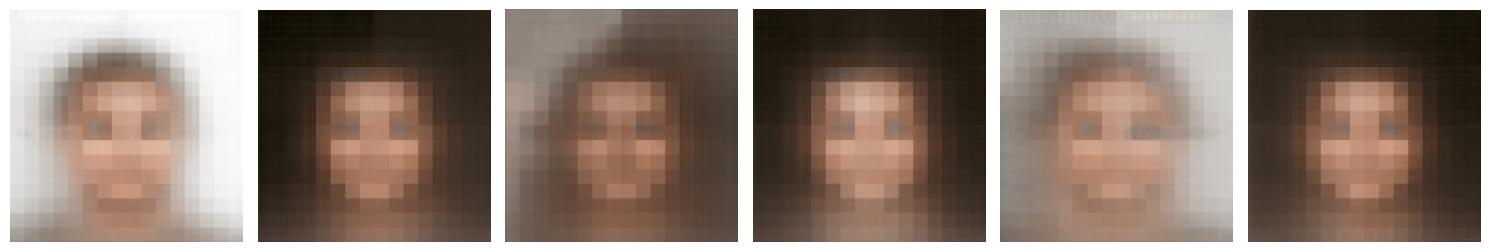

In [12]:
if os.path.exists(SAVE_PATH):
  ckpt = torch.load(SAVE_PATH, map_location=DEVICE)
  model = VanillaVAE(in_channels=3, latent_dim=ckpt['latent_dim'], hidden_dims=ckpt['hidden_dims']).to(DEVICE)
  model.load_state_dict(ckpt['model'])
else:
  raise FileNotFoundError(f"Model checkpoint not found at {SAVE_PATH}. Please ensure training was completed or a valid checkpoint exists.")


model.eval()
TEMPERATURE = 2.5 # Increased temperature for more diversity
z = torch.randn(6, model.latent_dim, device=DEVICE) * TEMPERATURE
with torch.no_grad():
    samples = model.decode(z).clamp(0, 1)

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i in range(6):
    axes[i].imshow(samples[i].permute(1, 2, 0).cpu())
    axes[i].axis('off')
plt.tight_layout()
plt.show()

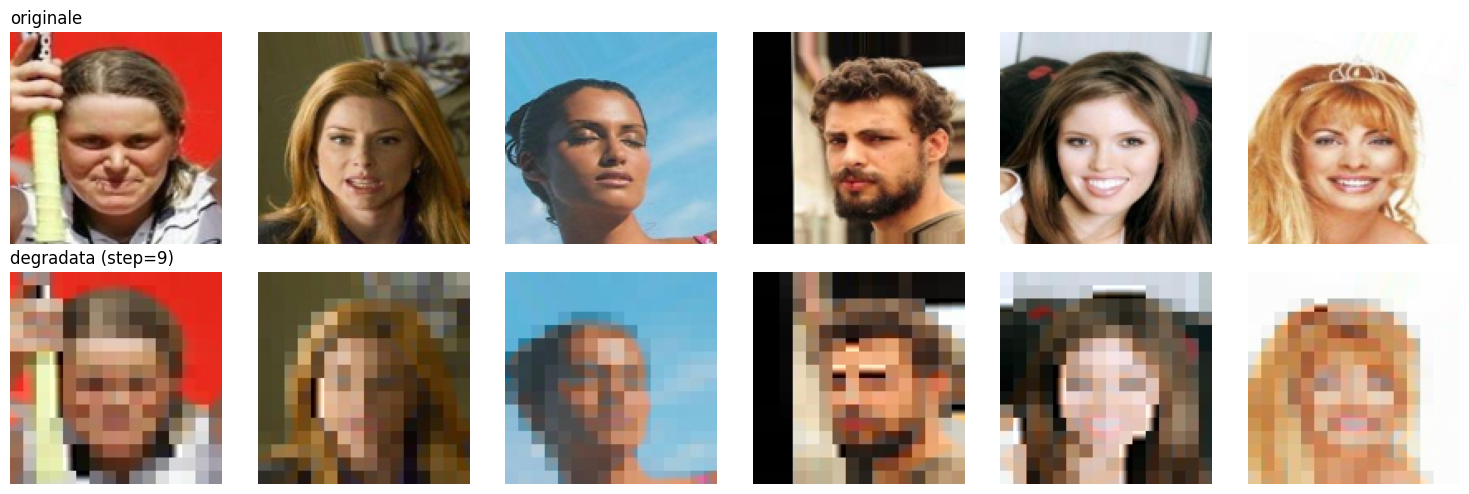

In [13]:
ds = DegradedFaceDataset(LOCAL_DATA_ROOT, patch_size=128)
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for i in range(6):
    idx = torch.randint(0, len(ds), (1,)).item()
    axes[0, i].imshow(Image.open(ds.paths[idx]).resize((128,128)))
    axes[0, i].axis('off')
    axes[1, i].imshow(ds[idx].permute(1,2,0).numpy())
    axes[1, i].axis('off')
axes[0,0].set_title('originale', loc='left')
axes[1,0].set_title('degradata (step=9)', loc='left')
plt.tight_layout()
plt.show()

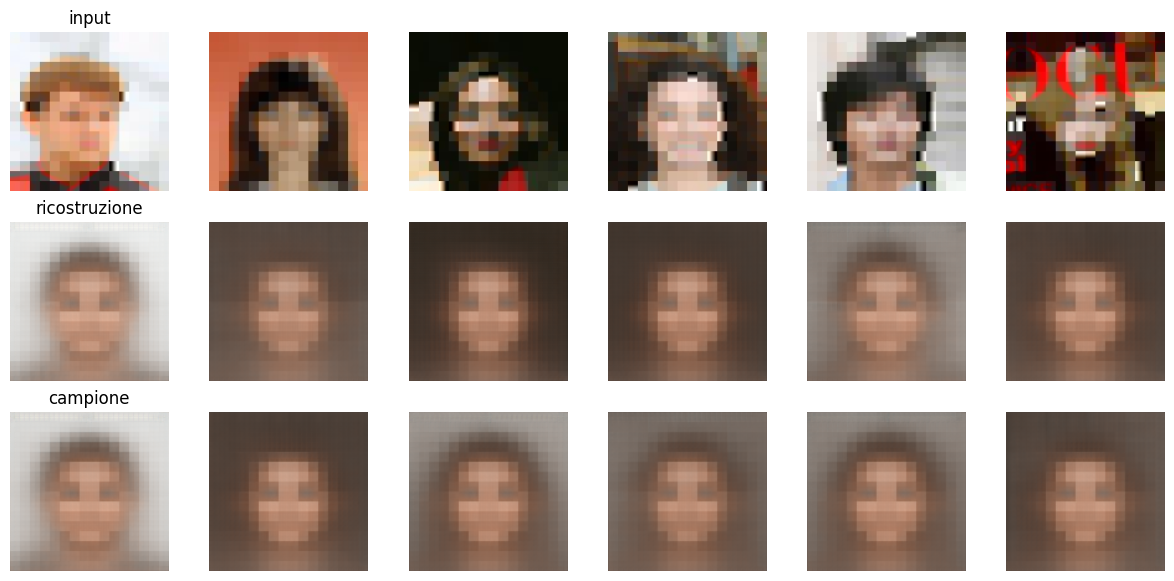

In [14]:
model.eval()
ds = DegradedFaceDataset(LOCAL_DATA_ROOT, patch_size=128)
batch = torch.stack([ds[i] for i in range(6)]).to(DEVICE)
with torch.no_grad():
    recon, _, mu, _ = model(batch)
fig, axes = plt.subplots(3, 6, figsize=(15, 7))
for i in range(6):
    axes[0,i].imshow(batch[i].cpu().permute(1,2,0)); axes[0,i].axis('off')
    axes[1,i].imshow(recon[i].cpu().clamp(0,1).permute(1,2,0)); axes[1,i].axis('off')
    axes[2,i].imshow(model.decode(torch.randn(1,LATENT_DIM).to(DEVICE))[0].detach()
                     .cpu().clamp(0,1).permute(1,2,0)); axes[2,i].axis('off')
axes[0,0].set_title('input'); axes[1,0].set_title('ricostruzione'); axes[2,0].set_title('campione')
plt.show()